## Preprocess
This section performs preprocessing on the ATAC-seq data. Steps include quality control, cell aggregation, normalization, and log transformation.

In [1]:
import scanpy as sc
import os
import subprocess
import sys
from src.data.atac_preprocess import quality_control
from src.data.atac_preprocess import deepen_atac_data

In [2]:
# NOTE: adata.var must contain the columns '#Chromosome', 'hg38_Start', and 'hg38_End'.
ATAC_FILE_PATH = "sample_data/PBMC169K"
sample_file = "atac_pbmc_benchmark_VIB_10xv1_1.h5ad"
adata = sc.read_h5ad(os.path.join(ATAC_FILE_PATH, sample_file))
adata.var['hg38_Start'] = adata.var['hg38_Start'].astype(int)
adata.var['hg38_End'] = adata.var['hg38_End'].astype(int)

In [4]:
adata.var.head()

,features,#Chromosome,hg38_Start,hg38_End
0,chr7:2955066-2955566,chr7,2955066,2955566
1,chr5:151253571-151254071,chr5,151253571,151254071
2,chr1:31639474-31639974,chr1,31639474,31639974
3,chr7:107038154-107038654,chr7,107038154,107038654
4,chr2:141201833-141202333,chr2,141201833,141202333


In [ ]:
ATAC_FILE_PATH = "sample_data/PBMC169K"
sample_file = "atac_pbmc_benchmark_VIB_10xv1_1.h5ad"
adata = sc.read_h5ad(os.path.join(ATAC_FILE_PATH, sample_file))
adata.var['hg38_Start'] = adata.var['hg38_Start'].astype(int)
adata.var['hg38_End'] = adata.var['hg38_End'].astype(int)

In [4]:
# Preprocessing parameters for quality control and data aggregation
# - min_features: Minimum number of features (peaks) required per cell
# - max_features: Maximum number of features allowed per cell
# - min_percent: Minimum percentage of cells expressing a feature
# - cell_type_col: Column name for cell type annotation
# - num_cell_merge: Number of cells to merge during cell aggregation
data_args = {
    "min_features": 650,
    "max_features": 16500,
    "min_percent": 0.01,
    "cell_type_col": "celltype",
    "num_cell_merge": 10
}
preprocess_data_path = os.path.join(ATAC_FILE_PATH, f'{sample_file.split(".h5ad")[0]}_qc_deepen_norm_log.h5ad')

In [ ]:
# either run the following or skip all the preprocessing and just load the already-processed data as is in the uncommented section below

ALREADY_PROCESSED = False # default false

if not ALREADY_PROCESSED:

    # quality control
    print(f"Before quality control: {adata.shape}")
    adata = quality_control(
        adata,
        min_features=data_args.get("min_features"),
        max_features=data_args.get("max_features"),
        min_percent=data_args.get("min_percent"),
        cell_type_col=data_args.get("cell_type_col", "cell type")
    )
    print(f"After quality control: {adata.shape}")
    # cell aggregation
    adata = deepen_atac_data(adata, num_cell_merge=10)
    # normalize and log1p
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    # write file
    adata.write_h5ad(preprocess_data_path)

if ALREADY_PROCESSED:

    # Skip all the preprocessing and just load the already-processed data
    preprocess_data_path = os.path.join(ATAC_FILE_PATH, f'{sample_file.split(".h5ad")[0]}_qc_deepen_norm_log.h5ad')
    adata = sc.read_h5ad(preprocess_data_path)

## run inference
This section runs inference using a pretrained chromatin foundation model. The embeddings for cells are generated and saved to the specified output path.

In [ ]:
# Configuration for running cell embedding inference
# - pretrain_checkpoint_path: Directory containing the pretrained model checkpoint
# - pretrain_model_name: File name of the pretrained model
# - pretrain_config_file: Configuration file used for model architecture and settings
# - batch_size: Batch size for inference
# - device: GPU device ID for computation
# - output_path: Directory to save the inferred cell embeddings (uses scratch for fast I/O)
inference_config = {
    "pretrain_checkpoint_path": "src/checkpoints",
    "pretrain_model_name": "model.pt",
    "pretrain_config_file": "chromfd_pretrain.yaml",
    "batch_size": 12,
    "device": 5,
    "output_path": str(os.path.join(ATAC_FILE_PATH, "cell_embedding"))
}

In [7]:
train_command = [
    sys.executable, '-m', 'src.cell_embedding',
    '--local_rank', f'{inference_config["device"]}',
    '--data_path', preprocess_data_path,
    '--output_path', inference_config['output_path'],
    '--pretrain_checkpoint_path', inference_config['pretrain_checkpoint_path'],
    '--pretrain_model_file', inference_config['pretrain_model_name'],
    '--pretrain_config_file', inference_config['pretrain_config_file'],
    '--batch_size', f'{inference_config["batch_size"]}',
    '--cell_type_col', data_args["cell_type_col"]
]

subprocess.run(train_command)

INFO:root:Reading h5ad file from sample_data/PBMC169K/atac_pbmc_benchmark_VIB_10xv1_1_qc_deepen_norm_log.h5ad
100%|██████████| 289/289 [03:11<00:00,  1.51it/s]
INFO:root:Embeddings shape: (2595, 264533) saved to sample_data/PBMC169K/cell_embedding/embeddings.h5ad


CompletedProcess(args=['/home/naimer/miniforge3/envs/chromfound/bin/python', '-m', 'src.cell_embedding', '--local_rank', '5', '--data_path', 'sample_data/PBMC169K/atac_pbmc_benchmark_VIB_10xv1_1_qc_deepen_norm_log.h5ad', '--output_path', 'sample_data/PBMC169K/cell_embedding', '--pretrain_checkpoint_path', 'src/checkpoints', '--pretrain_model_file', 'model.pt', '--pretrain_config_file', 'chromfd_pretrain.yaml', '--batch_size', '9', '--cell_type_col', 'celltype'], returncode=0)

## metric
This section evaluates the quality of the generated embeddings. It uses clustering metrics such as ARI, NMI, AMI, and FMI to assess performance.

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import fowlkes_mallows_score
def calculate_cluster(mat_in, true_label, random_state=23):
    num_label = len(np.unique(true_label))
    kmeans = KMeans(n_clusters=num_label, random_state=random_state).fit(mat_in)
    return kmeans.labels_

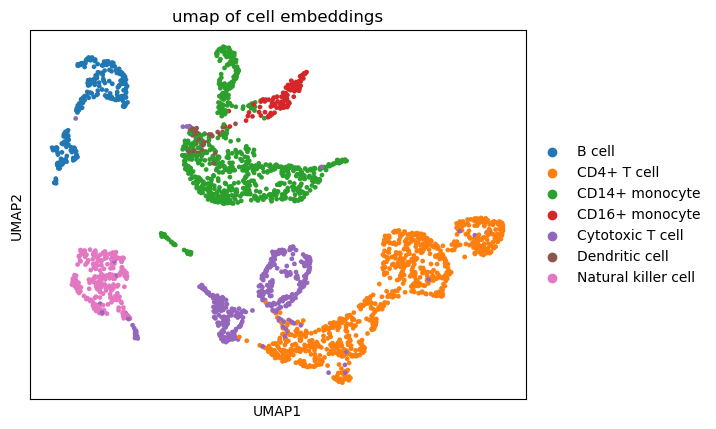

In [ ]:
adata = sc.read_h5ad(os.path.join(ATAC_FILE_PATH, "cell_embedding", "embeddings.h5ad"))
obs_df = pd.DataFrame(adata.obs['celltype'].tolist(), columns=['celltype'])
adata = sc.AnnData(X=adata.obsm['X_embedding'], obs=obs_df)
sc.tl.pca(adata, n_comps=10)
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color='celltype', title='umap of cell embeddings')

In [4]:
cluster_label = calculate_cluster(adata.obsm['X_pca'], adata.obs["celltype"])
ari_norm = adjusted_rand_score(adata.obs["celltype"], cluster_label)
nmi = normalized_mutual_info_score(adata.obs["celltype"], cluster_label)
ami = adjusted_mutual_info_score(adata.obs["celltype"], cluster_label)
fmi = fowlkes_mallows_score(adata.obs["celltype"], cluster_label)
print(
    f"ari: {ari_norm}, "
    f"nmi: {nmi}, "
    f"ami: {ami}, "
    f"fmi: {fmi}"
)

NameError: name 'adata' is not defined